In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('Dataset/nba_player_basket.csv',low_memory=False)
df.head(5)

,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,...,gameLabel,gameSubLabel,seriesGameNumber,attendance,arenaId,arenaName,arenaCity,arenaState,officials,gameDate
0,42500175,2026-04-29 22:00:00,Los Angeles,Lakers,1610612747,Houston,Rockets,1610612745,93,99,...,West First Round,Game 5,Game 5,19057.0,1000069,Crypto.com Arena,Los Angeles,CA,"Tony Brothers, Pat Fraher, Mitchell Ervin",2026-04-29 22:00:00
1,42500135,2026-04-29 19:30:00,Cleveland,Cavaliers,1610612739,Toronto,Raptors,1610612761,125,120,...,East First Round,Game 5,Game 5,19432.0,1000144,Rocket Arena,Cleveland,OH,"Scott Foster, Sean Wright, Gediminas Petraitis...",2026-04-29 19:30:00
2,42500105,2026-04-29 19:00:00,Detroit,Pistons,1610612765,Orlando,Magic,1610612753,116,109,...,East First Round,Game 5,Game 5,20062.0,624,Little Caesars Arena,Detroit,MI,"John Goble, Curtis Blair, Kevin Cutler, Tre Ma...",2026-04-29 19:00:00
3,42500155,2026-04-28 21:30:00,San Antonio,Spurs,1610612759,Portland,Trail Blazers,1610612757,114,95,...,West First Round,Game 5,Game 5,19063.0,1000118,Frost Bank Center,San Antonio,TX,"Sean Corbin, Marc Davis, Nick Buchert, Ray Acosta",2026-04-28 21:30:00
4,42500125,2026-04-28 20:00:00,New York,Knicks,1610612752,Atlanta,Hawks,1610612737,126,97,...,East First Round,Game 5,Game 5,19812.0,30,Madison Square Garden,New York,NY,"Courtney Kirkland, Josh Tiven, Justin Van Duyn...",2026-04-28 20:00:00


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73233 entries, 0 to 73232
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gameId            73233 non-null  int64  
 1   gameDateTimeEst   73233 non-null  object 
 2   hometeamCity      73226 non-null  object 
 3   hometeamName      73233 non-null  object 
 4   hometeamId        73233 non-null  int64  
 5   awayteamCity      73226 non-null  object 
 6   awayteamName      73233 non-null  object 
 7   awayteamId        73233 non-null  int64  
 8   homeScore         73233 non-null  int64  
 9   awayScore         73233 non-null  int64  
 10  winner            73233 non-null  int64  
 11  gameType          73233 non-null  object 
 12  gameSubtype       74 non-null     object 
 13  gameLabel         3997 non-null   object 
 14  gameSubLabel      282 non-null    object 
 15  seriesGameNumber  5777 non-null   object 
 16  attendance        1346 non-null   float6

In [5]:
df.shape

(73233, 23)

In [6]:
df.isnull().sum()

gameId                  0
gameDateTimeEst         0
hometeamCity            7
hometeamName            0
hometeamId              0
awayteamCity            7
awayteamName            0
awayteamId              0
homeScore               0
awayScore               0
winner                  0
gameType                0
gameSubtype         73159
gameLabel           69236
gameSubLabel        72951
seriesGameNumber    67456
attendance          71887
arenaId                 0
arenaName           71879
arenaCity           71879
arenaState          71888
officials           71879
gameDate                0
dtype: int64

In [7]:
df = df.drop(columns=['gameSubtype','gameLabel','gameSubLabel','seriesGameNumber','attendance','arenaName','arenaCity','arenaState','officials','arenaId'])
df.head(5)

,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameDate
0,42500175,2026-04-29 22:00:00,Los Angeles,Lakers,1610612747,Houston,Rockets,1610612745,93,99,1610612745,Playoffs,2026-04-29 22:00:00
1,42500135,2026-04-29 19:30:00,Cleveland,Cavaliers,1610612739,Toronto,Raptors,1610612761,125,120,1610612739,Playoffs,2026-04-29 19:30:00
2,42500105,2026-04-29 19:00:00,Detroit,Pistons,1610612765,Orlando,Magic,1610612753,116,109,1610612765,Playoffs,2026-04-29 19:00:00
3,42500155,2026-04-28 21:30:00,San Antonio,Spurs,1610612759,Portland,Trail Blazers,1610612757,114,95,1610612759,Playoffs,2026-04-28 21:30:00
4,42500125,2026-04-28 20:00:00,New York,Knicks,1610612752,Atlanta,Hawks,1610612737,126,97,1610612752,Playoffs,2026-04-28 20:00:00


In [8]:
# handling Feature: hometeamCity
mode_homeTeam = df['hometeamCity'].mode()[0]
df['hometeamCity'] = df['hometeamCity'].fillna(mode_homeTeam)
df.isnull().sum()

gameId             0
gameDateTimeEst    0
hometeamCity       0
hometeamName       0
hometeamId         0
awayteamCity       7
awayteamName       0
awayteamId         0
homeScore          0
awayScore          0
winner             0
gameType           0
gameDate           0
dtype: int64

In [9]:
# handling Feature: awayteamCity 
mode_awayTeam = df['awayteamCity'].mode()[0]
df['awayteamCity'] = df['awayteamCity'].fillna(mode_awayTeam)
df.isnull().sum()

gameId             0
gameDateTimeEst    0
hometeamCity       0
hometeamName       0
hometeamId         0
awayteamCity       0
awayteamName       0
awayteamId         0
homeScore          0
awayScore          0
winner             0
gameType           0
gameDate           0
dtype: int64

In [10]:
kolom_id = ['gameId','hometeamId','awayteamId']
df[kolom_id]=df[kolom_id].astype(object)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73233 entries, 0 to 73232
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   gameId           73233 non-null  object
 1   gameDateTimeEst  73233 non-null  object
 2   hometeamCity     73233 non-null  object
 3   hometeamName     73233 non-null  object
 4   hometeamId       73233 non-null  object
 5   awayteamCity     73233 non-null  object
 6   awayteamName     73233 non-null  object
 7   awayteamId       73233 non-null  object
 8   homeScore        73233 non-null  int64 
 9   awayScore        73233 non-null  int64 
 10  winner           73233 non-null  int64 
 11  gameType         73233 non-null  object
 12  gameDate         73233 non-null  object
dtypes: int64(3), object(10)
memory usage: 7.3+ MB


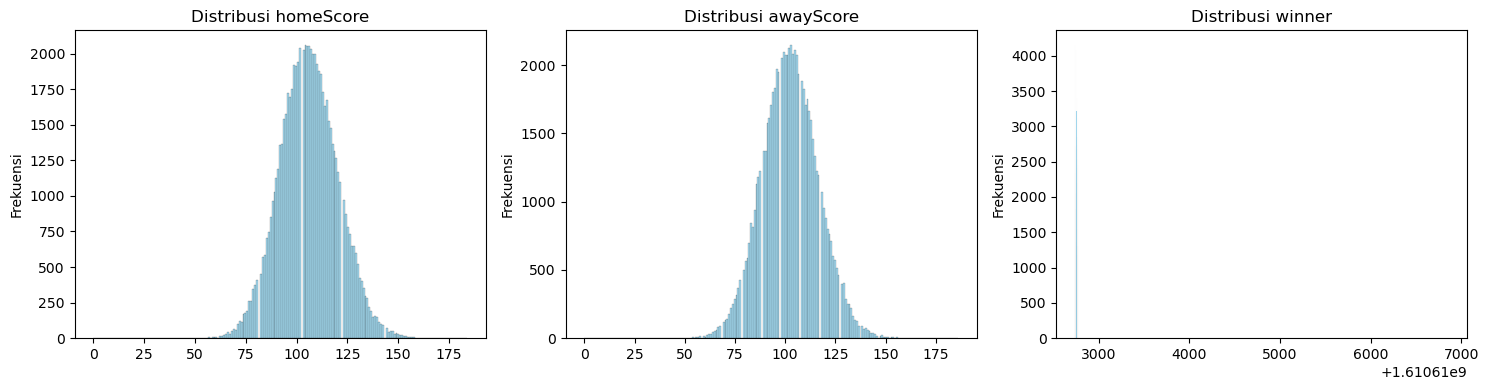

In [11]:
#analisis distribusi  feature numerik
feature_numerik = df.select_dtypes(include=[np.number])
nump_cols = feature_numerik.shape[1]
grid_cols =3
grid_rows = 1

fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(5 * grid_cols, 4 * grid_rows))
axes = axes.flatten()  # Meratakan matriks axes menjadi array 1D agar mudah diiterasi
for i, kolom in enumerate(feature_numerik.columns):
    sns.histplot(data=feature_numerik, x=kolom, kde=False, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribusi {kolom}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frekuensi')
plt.tight_layout()
plt.show()

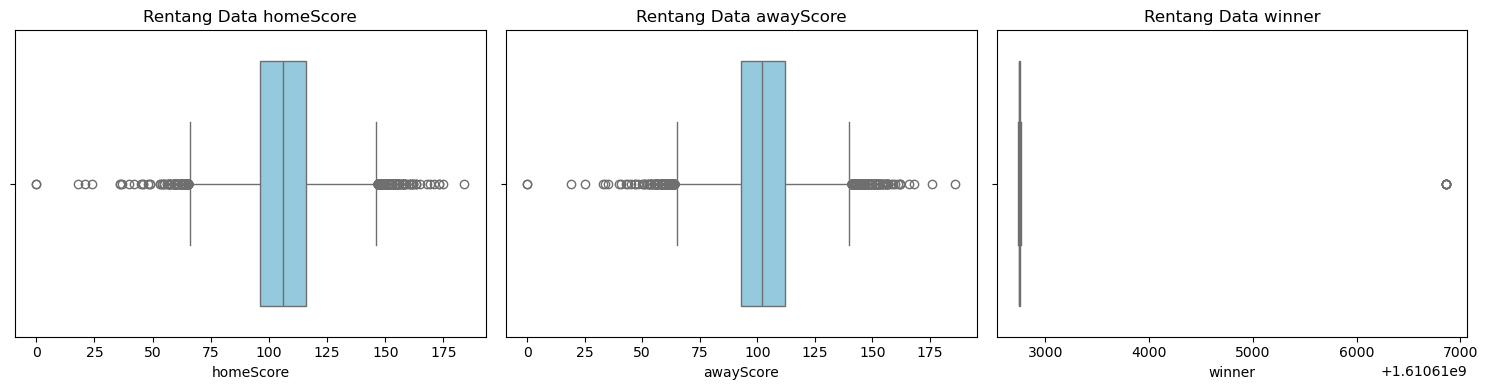

In [12]:
#distribusi feature numerik Boxplot
fig,axes = plt.subplots(grid_rows, grid_cols, figsize=(5 * grid_cols, 4 * grid_rows))
axes = axes.flatten()  # agar jadi 1D
for i, kolom in enumerate(feature_numerik.columns):
    sns.boxplot(data=feature_numerik, x=kolom, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Rentang Data {kolom}')
    axes[i].set_xlabel(kolom)
    axes[i].set_ylabel('')   
plt.tight_layout()
plt.show()

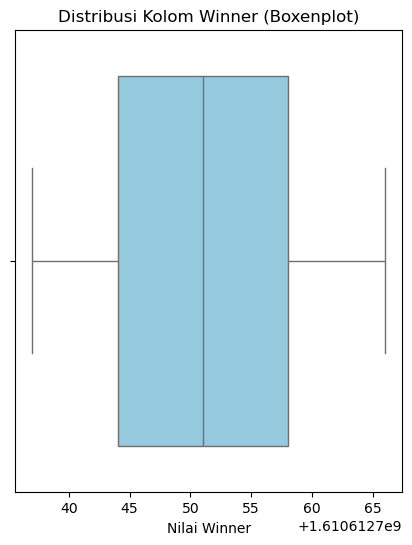

In [13]:
# handling data outlier :winner
quantile_winner = df['winner'].quantile([0.25,0.75])
IQR = quantile_winner.loc[0.75]-quantile_winner.loc[0.25]
batas_bawah = quantile_winner.loc[0.25] - 1.5  * IQR
batas_atas = quantile_winner.loc[0.75] + 1.5 * IQR
df = df[~((df['winner'] < batas_bawah) | (df['winner'] > batas_atas))]

data_winner = df['winner']
plt.figure(figsize=(5, 6))
sns.boxplot(x=data_winner, color='skyblue')
plt.title('Distribusi Kolom Winner (Boxenplot)')
plt.xlabel('Nilai Winner')
plt.ylabel('') 
plt.show()

In [14]:
df.isna().sum()

gameId             0
gameDateTimeEst    0
hometeamCity       0
hometeamName       0
hometeamId         0
awayteamCity       0
awayteamName       0
awayteamId         0
homeScore          0
awayScore          0
winner             0
gameType           0
gameDate           0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

## Analisis Performa & Keunggulan Tim

   1. Hitung berapa persentase total pertandingan yang berhasil dimenangkan oleh tim tuan rumah (hometeamName). Apakah terdapat indikasi kuat adanya keuntungan bermain di kandang (rasio > 50%)?
   2. Tim manakah (awayteamName) yang memiliki rasio kemenangan tandang tertinggi saat mereka bermain di luar kota asal mereka sendiri?
   3. Jika dihitung berdasarkan rata-rata total skor per pertandingan (homeScore + awayScore), kota mana (hometeamCity) yang pertandingannya paling produktif menghasilkan poin total?
   4. Cari tim yang memiliki nilai standar deviasi selisih skor (selisih absolut antara homeScore dan awayScore) paling kecil saat bermain di kandang sendiri.
   5. Identifikasi pasangan pertandingan kota (hometeamCity vs awayteamCity) yang paling sering bertemu dalam dataset, lalu hitung tim mana yang memimpin rekor kemenangan.

## Analisis Pola Waktu & Karakteristik Kompetisi

   1. Ekstrak nama hari dari gameDate. Apakah rata-rata skor yang dicetak oleh tim tamu cenderung lebih rendah pada hari kerja (weekdays) dibandingkan akhir pekan (weekends)?
   2. Kelompokkan data berdasarkan komponen bulan dari gameDate. Tunjukkan tren rata-rata homeScore dari bulan ke bulan menggunakan teknik agregasi data.
   3. Ekstrak komponen jam dari gameDateTimeEst. Apakah pertandingan yang dimulai di atas jam 18:00 (malam hari) memiliki rata-rata selisih skor yang lebih ketat dibanding laga siang hari?
   4. Bandingkan nilai median dari total skor pertandingan untuk setiap kategori di gameType. Apakah tipe pertandingan tertentu terbukti berjalan lebih defensif (skor lebih rendah)?
   5. Identifikasi tim yang memiliki persentase kemenangan tertinggi khusus pada gameType yang bukan musim reguler (misal: kategori playoff atau turnamen).

## Analisis Distribusi Skor, Kontribusi Poin, dan Dominasi Klasemen

   1. Buat fitur baru yang menghitung persentase kontribusi poin tim tuan rumah terhadap total skor pertandingan (homeScore / (homeScore + awayScore)). Tim mana yang memiliki rasio kontribusi tertinggi saat bermain di kandang?
   2. Hitung rata-rata skor yang dicetak (points scored) dan rata-rata kebobolan (points allowed) untuk setiap tim di sepanjang dataset. Tampilkan 3 tim dengan produktivitas serangan terbaik dan 3 tim dengan pertahanan terkuat.
   3. Hitung selisih skor absolut antara kedua tim di setiap laga. Tentukan nilai rata-rata, median, dan modus dari selisih skor tersebut untuk melihat seberapa ketat peta persaingan liga secara umum.
   4. Gunakan kolom winner untuk menghitung total jumlah kemenangan dari setiap tim (gabungan saat menjadi home maupun away). Urutkan tim dari yang mengoleksi kemenangan terbanyak hingga tersedikit.
   5. Berapa persen pertandingan dalam dataset yang berakhir dengan selisih skor sangat tipis (misal $\le 3$ poin)? Kelompokkan hasil persentase ini berdasarkan masing-masing gameType untuk melihat di fase mana laga sengit paling sering terjadi.


In [16]:
df.head(2)

,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameDate
0,42500175,2026-04-29 22:00:00,Los Angeles,Lakers,1610612747,Houston,Rockets,1610612745,93,99,1610612745,Playoffs,2026-04-29 22:00:00
1,42500135,2026-04-29 19:30:00,Cleveland,Cavaliers,1610612739,Toronto,Raptors,1610612761,125,120,1610612739,Playoffs,2026-04-29 19:30:00


## Analisis Performa & Keunggulan Tim

   1. Hitung berapa persentase total pertandingan yang berhasil dimenangkan oleh tim tuan rumah (hometeamName). Apakah terdapat indikasi kuat adanya keuntungan bermain di kandang (rasio > 50%)?
   2. Tim manakah (awayteamName) yang memiliki rasio kemenangan tandang tertinggi saat mereka bermain di luar kota asal mereka sendiri?
   3. Jika dihitung berdasarkan rata-rata total skor per pertandingan (homeScore + awayScore), kota mana (hometeamCity) yang pertandingannya paling produktif menghasilkan poin total?
   4. Cari tim yang memiliki nilai standar deviasi selisih skor (selisih absolut antara homeScore dan awayScore) paling kecil saat bermain di kandang sendiri.
   5. Identifikasi pasangan pertandingan kota (hometeamCity vs awayteamCity) yang paling sering bertemu dalam dataset, lalu hitung tim mana yang memimpin rekor kemenangan.

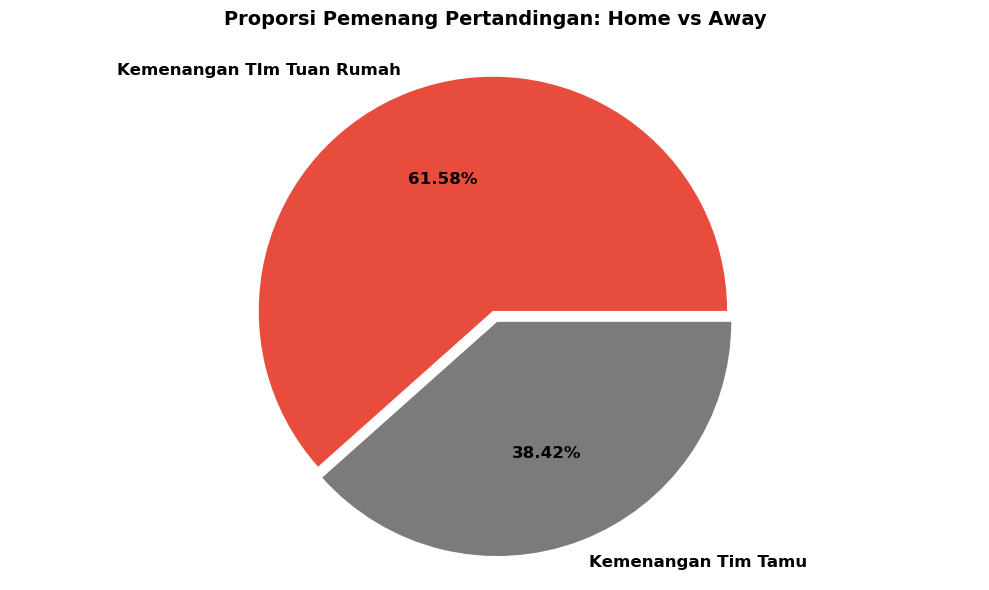

Total Pertandingan di Liga          : 73226 laga
Total Kemenangan Tim Tuan Rumah     : 45093 laga
Rasio Kemenangan Tuan Rumah (Home)  : 61.58%

Kesimpulan: Terdapat INDIKASI KUAT adanya keuntungan bermain di kandang (Home Advantage), karena rasionya melebihi 50%.


In [17]:
# soal nomor 1
# 1. Hitung berapa persentase total pertandingan yang berhasil dimenangkan oleh tim tuan rumah (hometeamName). Apakah terdapat indikasi kuat adanya keuntungan bermain di kandang (rasio > 50%)?
data=df[['hometeamId','winner','hometeamName']].copy()
winner_team = data[data['hometeamId']==data['winner']].reset_index(drop=True)
count_match= data['winner'].count()
count_winner= data[data['hometeamId']==data['winner']]['winner'].count()
presentase = ((count_winner/count_match) * 100 ).round(2)

persentase_away = (100-presentase).round(2)
label = ['Kemenangan TIm Tuan Rumah','Kemenangan Tim Tamu']
colors = ['#e74c3c', '#7b7b7b']
size = [presentase,persentase_away]

plt.figure(figsize=(10, 6))
plt.pie(size, explode=(0.05,0), labels=label, colors=colors, autopct='%1.2f%%', textprops={'fontsize': 12, 'weight': 'bold'})
plt.title('Proporsi Pemenang Pertandingan: Home vs Away', fontsize=14, weight='bold', pad=20)
plt.axis('equal')  # Memastikan diagram berbentuk lingkaran sempurna
plt.tight_layout()
plt.show()

print(f"Total Pertandingan di Liga          : {count_match} laga")
print(f"Total Kemenangan Tim Tuan Rumah     : {count_winner} laga")
print(f"Rasio Kemenangan Tuan Rumah (Home)  : {presentase:.2f}%")

if presentase > 50.0:
    print("\nKesimpulan: Terdapat INDIKASI KUAT adanya keuntungan bermain di kandang (Home Advantage), karena rasionya melebihi 50%.")
else:
    print("\nKesimpulan: TIDAK TERDAPAT indikasi keuntungan bermain di kandang, karena rasionya tidak melebihi 50%.")

In [18]:
df.head(2)

,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameDate
0,42500175,2026-04-29 22:00:00,Los Angeles,Lakers,1610612747,Houston,Rockets,1610612745,93,99,1610612745,Playoffs,2026-04-29 22:00:00
1,42500135,2026-04-29 19:30:00,Cleveland,Cavaliers,1610612739,Toronto,Raptors,1610612761,125,120,1610612739,Playoffs,2026-04-29 19:30:00


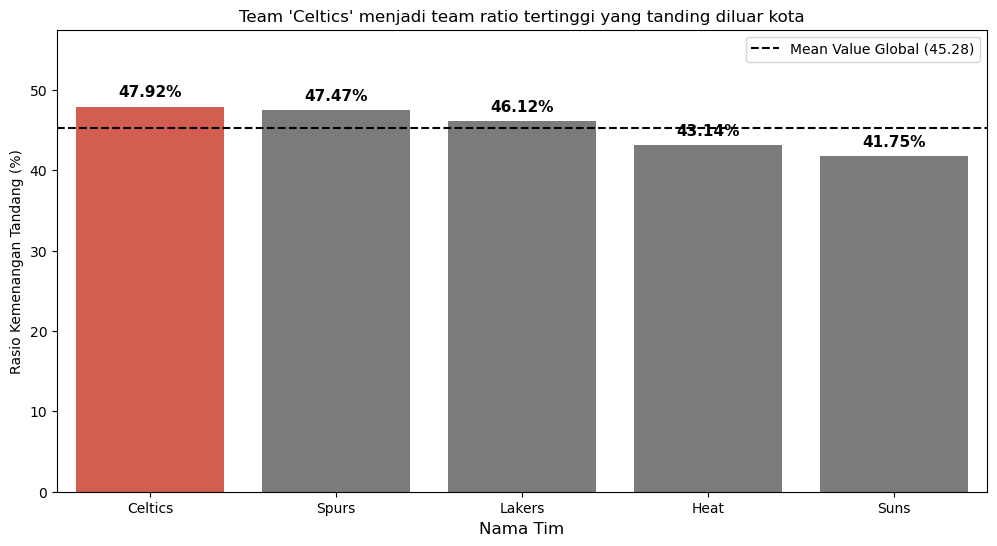

fTeam 'Celtics' menjadi team ratio menang tertinggi 47.92% yang tanding di luar kota mereka


In [19]:
#soal nomor 2
# 2. Tim manakah (awayteamName) yang memiliki rasio kemenangan tandang tertinggi saat mereka bermain di luar kota asal mereka sendiri?
data = df[['hometeamCity','awayteamName','winner','awayteamId','hometeamId',]].copy()
data_luarkota = data[data['hometeamCity'] != data['awayteamName']] # hitung jumlah bertanding
total_mainaway = data_luarkota.groupby('awayteamName')['winner'].count().reset_index(name='total_laga_away')

data_winneraway = data[data['awayteamId']==data['winner']]
total_winneraway = data_winneraway.groupby('awayteamName')['winner'].count().reset_index(name='total_winner_away')

ratio_away = total_mainaway.merge(total_winneraway,on='awayteamName',how='left')# gabungkan (fokus tabel kiri 'total_mainaway')
ratio_away['Ration_winner'] = ((ratio_away['total_winner_away']/ratio_away['total_laga_away'])*100).round(2)

topration_team = ratio_away[ratio_away['total_laga_away'] > ratio_away['total_laga_away'].mean()].sort_values(by='Ration_winner',ascending=False).head(5).reset_index(drop=True)

top_team = topration_team['Ration_winner'].max()
top_nameteam = topration_team['awayteamName'].loc[0]
meanValue = topration_team['Ration_winner'].mean().round(2)
colors = ['#e74c3c' if (x == top_team) else "#7b7b7b" for x in topration_team['Ration_winner']]

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=topration_team, x='awayteamName', y='Ration_winner', hue='awayteamName',palette=colors)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}%', 
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 5),  # Jarak 5 point ke atas
                textcoords="offset points",
                ha='center', va='bottom', 
                fontweight='bold', fontsize=11)
plt.ylim(0, topration_team['Ration_winner'].max() * 1.2)

plt.axhline(meanValue, color='black', linestyle='--', label=f'Mean Value Global ({meanValue})')
plt.title(f"Team '{top_nameteam}' menjadi team ratio tertinggi yang tanding diluar kota")
plt.xlabel('Nama Tim', fontsize=12)
plt.ylabel('Rasio Kemenangan Tandang (%)')
plt.legend(loc='upper right')
plt.legend()
plt.show()

print(f"fTeam '{top_nameteam}' menjadi team ratio menang tertinggi {top_team:.2f}% yang tanding di luar kota mereka")

In [20]:
df.head(2)

,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameDate
0,42500175,2026-04-29 22:00:00,Los Angeles,Lakers,1610612747,Houston,Rockets,1610612745,93,99,1610612745,Playoffs,2026-04-29 22:00:00
1,42500135,2026-04-29 19:30:00,Cleveland,Cavaliers,1610612739,Toronto,Raptors,1610612761,125,120,1610612739,Playoffs,2026-04-29 19:30:00


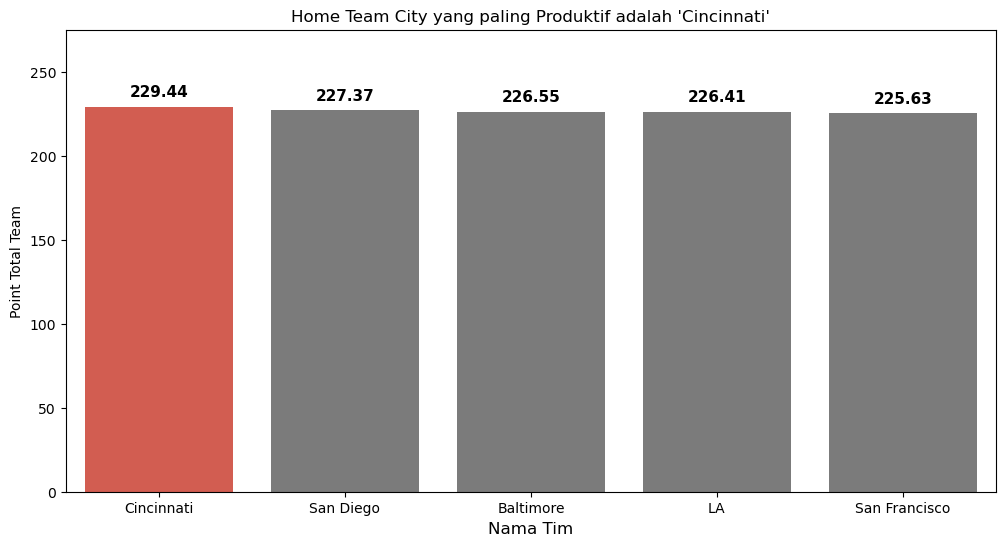

Home Team yang paling produktif adalah 'Cincinnati' dengan point sebanyak 229.44


In [59]:
# soal nomor 3
#  3. Jika dihitung berdasarkan rata-rata total skor per pertandingan (homeScore + awayScore), kota mana (hometeamCity) yang pertandingannya paling produktif menghasilkan poin total?
data = df[['hometeamCity','homeScore','awayScore']].copy()
data['total_score'] = data['awayScore']+data['homeScore']
mean_score = data.groupby('hometeamCity')['total_score'].mean().reset_index()
top5_point = mean_score.sort_values(by='total_score',ascending=False).head(5).reset_index(drop=True).round(2)

#visualisasi cooming soon
top5_point
top_team = top5_point.loc[top5_point['total_score'].idxmax()]
colors = ['#e74c3c' if (x == top_team.total_score) else "#7b7b7b" for x in top5_point['total_score']]

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top5_point, x='hometeamCity', y='total_score', hue='hometeamCity',palette=colors)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}', 
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 5),  # Jarak 5 point ke atas
                textcoords="offset points",
                ha='center', va='bottom', 
                fontweight='bold', fontsize=11)
plt.ylim(0, top5_point['total_score'].max() * 1.2)
plt.title(f"Home Team City yang paling Produktif adalah '{top_team.hometeamCity}'")
plt.xlabel('Nama Tim', fontsize=12)
plt.ylabel('Point Total Team')
plt.show()
print(f"Home Team yang paling produktif adalah '{top_team.hometeamCity}' dengan point sebanyak {top_team.total_score}")


In [22]:
df.head(2)

,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameDate
0,42500175,2026-04-29 22:00:00,Los Angeles,Lakers,1610612747,Houston,Rockets,1610612745,93,99,1610612745,Playoffs,2026-04-29 22:00:00
1,42500135,2026-04-29 19:30:00,Cleveland,Cavaliers,1610612739,Toronto,Raptors,1610612761,125,120,1610612739,Playoffs,2026-04-29 19:30:00


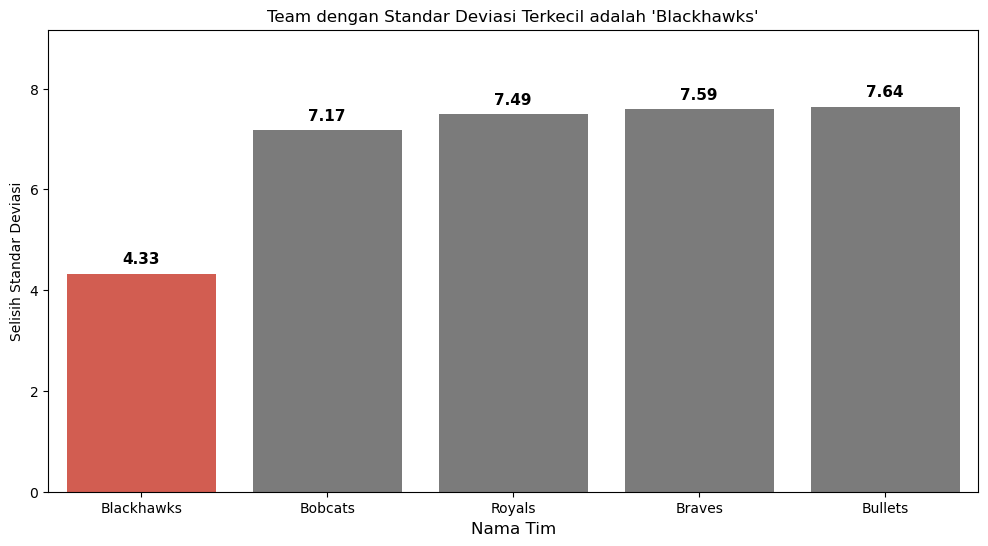

Team yang memiliki nilai Standar Deviasi Selisih paling kecil adalah 'Blackhawks' sebesar 4.33


In [73]:
#soal nomor 4
# 4.Cari tim yang memiliki nilai standar deviasi selisih skor (selisih absolut antara homeScore dan awayScore) paling kecil saat bermain di kandang sendiri.
data= df[['hometeamName','homeScore','awayScore']].copy()
data['selisih_score'] = (data['homeScore']-data['awayScore']).abs()
std_score = data.groupby('hometeamName')['selisih_score'].agg(['std']).reset_index()
min5_stdscore = std_score.sort_values(by='std').reset_index(drop=True).head(5).round(2)

min_stdScore = min5_stdscore.loc[min5_stdscore['std'].idxmin()]
colors = ['#e74c3c' if (x == min_stdScore['std']) else "#7b7b7b" for x in min5_stdscore['std']]

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=min5_stdscore, x='hometeamName', y='std', hue='hometeamName',palette=colors)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}', 
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 5),  # Jarak 5 point ke atas
                textcoords="offset points",
                ha='center', va='bottom', 
                fontweight='bold', fontsize=11)
plt.ylim(0, min5_stdscore['std'].max() * 1.2)
plt.title(f"Team dengan Standar Deviasi Terkecil adalah '{min_stdScore.hometeamName}'")
plt.xlabel('Nama Tim', fontsize=12)
plt.ylabel('Selisih Standar Deviasi')
plt.show()
print(f"Team yang memiliki nilai Standar Deviasi Selisih paling kecil adalah '{min_stdScore.hometeamName}' sebesar {min_stdScore['std']}")


In [24]:
df.head(2)

,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameDate
0,42500175,2026-04-29 22:00:00,Los Angeles,Lakers,1610612747,Houston,Rockets,1610612745,93,99,1610612745,Playoffs,2026-04-29 22:00:00
1,42500135,2026-04-29 19:30:00,Cleveland,Cavaliers,1610612739,Toronto,Raptors,1610612761,125,120,1610612739,Playoffs,2026-04-29 19:30:00


In [ ]:
#soal nomor 5
# 5. Identifikasi pasangan pertandingan kota (hometeamCity vs awayteamCity) yang paling sering bertemu dalam dataset, lalu hitung tim mana yang memimpin rekor kemenangan.
data=df[['hometeamCity','awayteamCity','homeScore','awayScore','winner','hometeamId','awayteamId']].copy()
#cari pertandingan yang sering
data['match_pair'] = data['hometeamCity'] + ' VS ' + data['awayteamCity']
frequent_matches = data.groupby('match_pair').agg(count_tanding=('winner','count')).reset_index()
matchtop_pair = frequent_matches.sort_values(by='count_tanding',ascending=False)['match_pair'].iloc[0]

most_Match = data.loc[data['match_pair']==matchtop_pair].copy()
recor_winner = most_Match['winner'].value_counts().reset_index()
recor_winner.columns = ['IDWinner','Jumlah_Kemenangan']
recor_winner['Name_Team'] = recor_winner['IDWinner'].map(data.set_index('hometeamId')['hometeamCity'].to_dict())#cari nama

top_recorWinner = recor_winner.loc[recor_winner['Jumlah_Kemenangan'].idxmax()]
colors = ['#e74c3c' if (x == top_recorWinner.Jumlah_Kemenangan) else "#7b7b7b" for x in recor_winner['Jumlah_Kemenangan']]

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=recor_winner, x='Name_Team', y='Jumlah_Kemenangan', hue='Name_Team',palette=colors)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}', 
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 5),  # Jarak 5 point ke atas
                textcoords="offset points",
                ha='center', va='bottom', 
                fontweight='bold', fontsize=11)
plt.ylim(0, recor_winner['Jumlah_Kemenangan'].max() * 1.2)
plt.title(f"Tim '{top_recorWinner.Name_Team}' memimpin rekor kemenangan Terbanyal")
plt.xlabel('Nama Tim', fontsize=12)
plt.ylabel('Jumlah Kemenangan',fontsize=12)
plt.show()
print(f"dalam pertandingan paling Sering {matchtop_pair}, Tim {top_recorWinner.Name_Team} memimpin rekor kemenangan sebanyak {top_recorWinner.Jumlah_Kemenangan}")
recor_winner

,IDWinner,Jumlah_Kemenangan,Name_Team
0,1610612738,231,Boston
1,1610612755,65,Syracuse
2,1610612744,14,Philadelphia


In [26]:
df.head(2)

,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameDate
0,42500175,2026-04-29 22:00:00,Los Angeles,Lakers,1610612747,Houston,Rockets,1610612745,93,99,1610612745,Playoffs,2026-04-29 22:00:00
1,42500135,2026-04-29 19:30:00,Cleveland,Cavaliers,1610612739,Toronto,Raptors,1610612761,125,120,1610612739,Playoffs,2026-04-29 19:30:00


## Analisis Pola Waktu & Karakteristik Kompetisi

   1. Ekstrak nama hari dari gameDate. Apakah rata-rata skor yang dicetak oleh tim tamu cenderung lebih rendah pada hari kerja (weekdays) dibandingkan akhir pekan (weekends)?
   2. Kelompokkan data berdasarkan komponen bulan dari gameDate. Tunjukkan tren rata-rata homeScore dari bulan ke bulan menggunakan teknik agregasi data.
   3. Ekstrak komponen jam dari gameDateTimeEst. Apakah pertandingan yang dimulai di atas jam 18:00 (malam hari) memiliki rata-rata selisih skor yang lebih ketat dibanding laga siang hari?
   4. Bandingkan nilai median dari total skor pertandingan untuk setiap kategori di gameType. Apakah tipe pertandingan tertentu terbukti berjalan lebih defensif (skor lebih rendah)?
   5. Identifikasi tim yang memiliki persentase kemenangan tertinggi khusus pada gameType yang bukan musim reguler (misal: kategori playoff atau turnamen).

In [27]:
df.head(2)

,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameDate
0,42500175,2026-04-29 22:00:00,Los Angeles,Lakers,1610612747,Houston,Rockets,1610612745,93,99,1610612745,Playoffs,2026-04-29 22:00:00
1,42500135,2026-04-29 19:30:00,Cleveland,Cavaliers,1610612739,Toronto,Raptors,1610612761,125,120,1610612739,Playoffs,2026-04-29 19:30:00


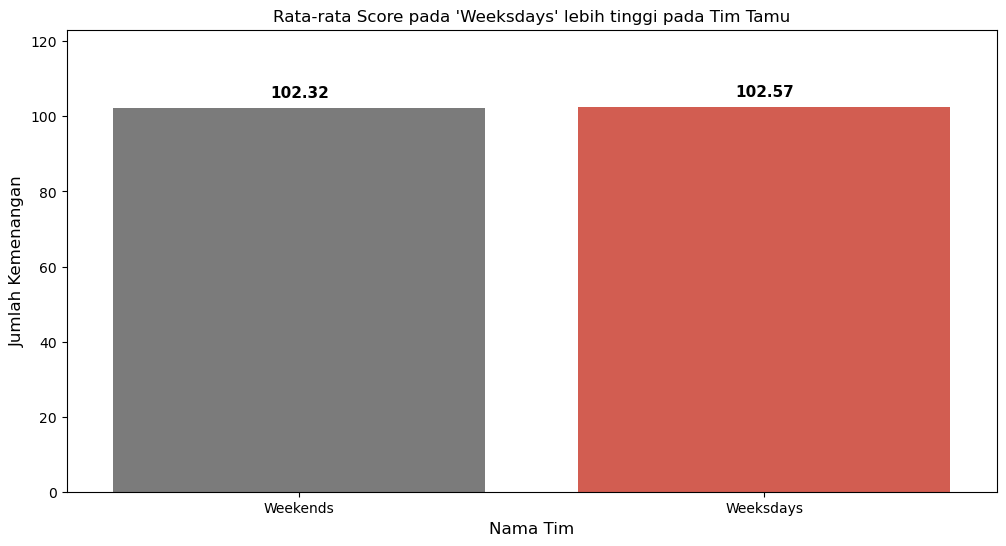

Rata-Rata Score Tim Tamu lebih besar 102.57 di Weeksdays dari pada di Weekends sebesar 102.32


In [106]:
#soal nomor 1
# 1. Ekstrak nama hari dari gameDate. Apakah rata-rata skor yang dicetak oleh tim tamu cenderung lebih rendah pada hari kerja (weekdays) dibandingkan akhir pekan (weekends)?
data = df[['gameDate','awayteamCity','awayScore']].copy()
weekends =  ["Saturday", "Sunday"]
data['gameDate'] = pd.to_datetime(data['gameDate'])
data["gameDate"] = data["gameDate"].dt.day_name()
data['type_week'] = data['gameDate'].apply(lambda x : 'Weekends' if x in weekends else 'Weeksdays')
avg_week = data.groupby('type_week').agg(avg_score=('awayScore','mean')).reset_index().round(2)

top_week = avg_week.loc[avg_week['avg_score'].idxmax()]
colors = ['#e74c3c' if (x ==top_week.avg_score) else "#7b7b7b" for x in avg_week['avg_score']]

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=avg_week, x='type_week', y='avg_score', hue='type_week',palette=colors)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}', 
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 5),  # Jarak 5 point ke atas
                textcoords="offset points",
                ha='center', va='bottom', 
                fontweight='bold', fontsize=11)
plt.ylim(0, avg_week['avg_score'].max() * 1.2)
plt.title(f"Rata-rata Score pada '{top_week.type_week}' lebih tinggi pada Tim Tamu")
plt.xlabel('Nama Tim', fontsize=12)
plt.ylabel('Jumlah Kemenangan',fontsize=12)
plt.show()
print(f"Rata-Rata Score Tim Tamu lebih besar {avg_week.loc[1].avg_score} di {avg_week.loc[1].type_week} dari pada di {avg_week.loc[0].type_week} sebesar {avg_week.loc[0].avg_score}" )

In [29]:
df.head(2)

,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameDate
0,42500175,2026-04-29 22:00:00,Los Angeles,Lakers,1610612747,Houston,Rockets,1610612745,93,99,1610612745,Playoffs,2026-04-29 22:00:00
1,42500135,2026-04-29 19:30:00,Cleveland,Cavaliers,1610612739,Toronto,Raptors,1610612761,125,120,1610612739,Playoffs,2026-04-29 19:30:00


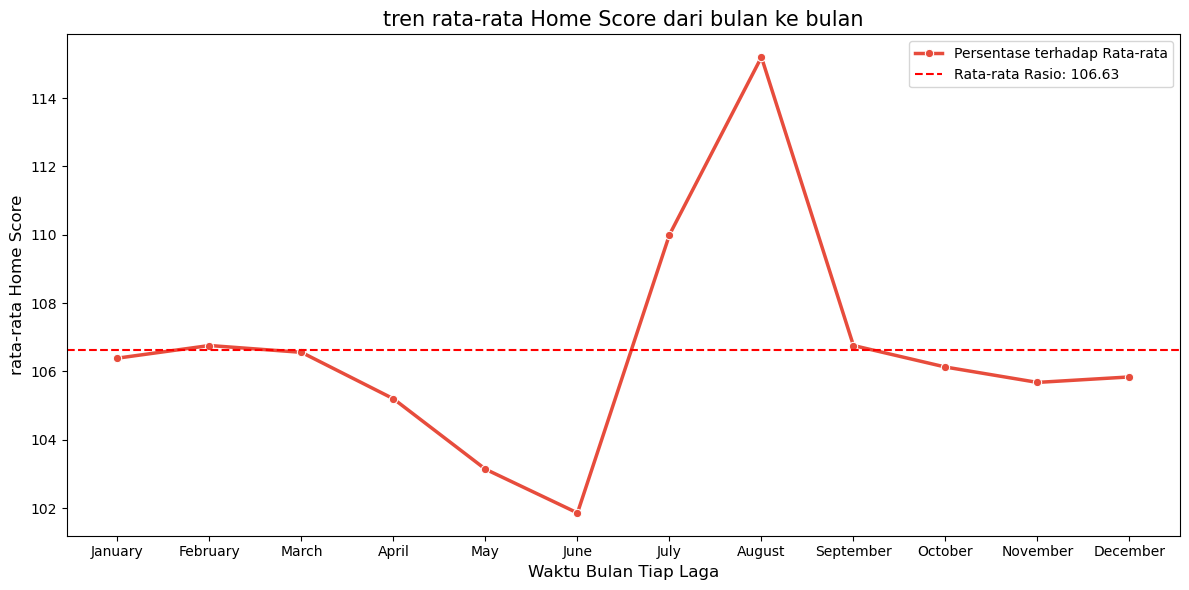

In [96]:
# soal nomor 2
# 2. Kelompokkan data berdasarkan komponen bulan dari gameDate. Tunjukkan tren rata-rata homeScore dari bulan ke bulan menggunakan teknik agregasi data.
data = df[['gameDate','hometeamCity','homeScore']].copy()
data['gameDate'] = pd.to_datetime(data['gameDate'])
data['gameDate'] = data['gameDate'].dt.strftime('%B')

urutan_bulan = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
avg_mount = data.groupby('gameDate').agg(avg_mount=('homeScore','mean')).reset_index().round(2)
#diurutkan berdasarkan bulan
avg_mount['gameDate'] = pd.Categorical(avg_mount['gameDate'],categories=urutan_bulan,ordered=True)
avg_mount = avg_mount.sort_values(by='gameDate').reset_index(drop=True)
mean_line_val = avg_mount['avg_mount'].mean().round(2)

plt.figure(figsize=(12, 6))
sns.lineplot(x=avg_mount['gameDate'], y=avg_mount['avg_mount'], marker='o', color='#e74c3c', linewidth=2.5, label='Persentase terhadap Rata-rata')
# plt.fill_between(avg_mount['gameDate'], avg_mount['avg_mount'], alpha=0.2, color='#e74c3c')
plt.axhline(mean_line_val, color='red', linestyle='--', label=f'Rata-rata Rasio: {mean_line_val:.2f}')
plt.title('tren rata-rata Home Score dari bulan ke bulan', fontsize=15)
plt.xlabel('Waktu Bulan Tiap Laga', fontsize=12)
plt.ylabel('rata-rata Home Score', fontsize=12)
plt.xticks(avg_mount['gameDate']) 
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
df.head(2)

,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameDate
0,42500175,2026-04-29 22:00:00,Los Angeles,Lakers,1610612747,Houston,Rockets,1610612745,93,99,1610612745,Playoffs,2026-04-29 22:00:00
1,42500135,2026-04-29 19:30:00,Cleveland,Cavaliers,1610612739,Toronto,Raptors,1610612761,125,120,1610612739,Playoffs,2026-04-29 19:30:00


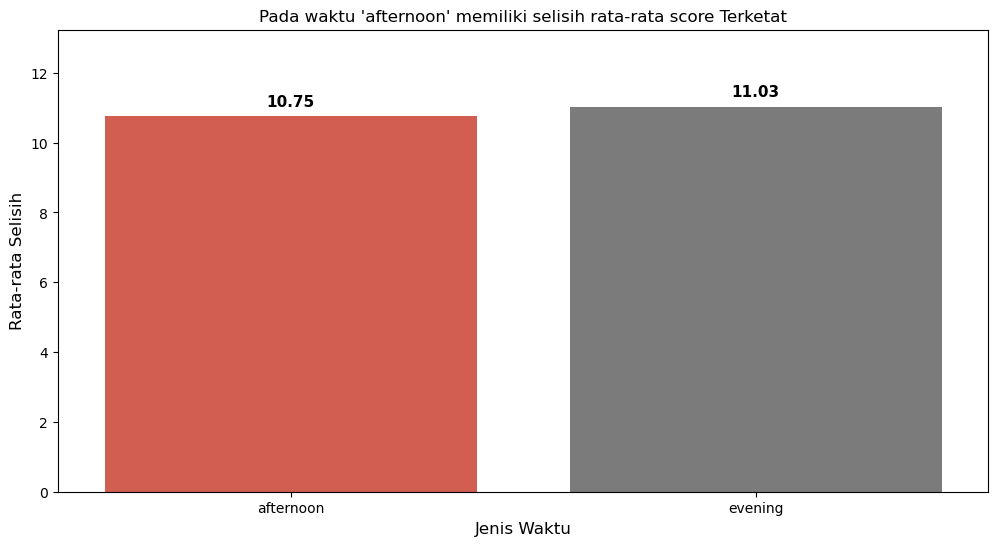


Waktu dengan pertandingan terketat: afternoon (10.75)


In [109]:
#soal nomor 3
# 3. Ekstrak komponen jam dari gameDateTimeEst. Apakah pertandingan yang dimulai di atas jam 18:00 (malam hari) memiliki rata-rata selisih skor yang lebih ketat dibanding laga siang hari?
data= df[['gameDate','homeScore','awayScore']].copy() 
data['selisih_score'] = (data['homeScore']-data['awayScore']).abs()
data['gameDate'] = pd.to_datetime(data['gameDate'])
data['gameDate'] = data['gameDate'].dt.hour
limit_hour = 18
data['label_time'] = data['gameDate'].apply(lambda x: 'evening' if x >= limit_hour else 'afternoon')
avg_deference = data.groupby('label_time').agg(avg_selisih=('selisih_score','mean')).reset_index().sort_values(by='avg_selisih').round(2)

waktu_terketat = avg_deference.loc[avg_deference['avg_selisih'].idxmin()]
colors = ['#e74c3c' if (x ==waktu_terketat.avg_selisih) else "#7b7b7b" for x in avg_deference['avg_selisih']]

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=avg_deference, x='label_time', y='avg_selisih', hue='label_time',palette=colors)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}', 
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 5),  # Jarak 5 point ke atas
                textcoords="offset points",
                ha='center', va='bottom', 
                fontweight='bold', fontsize=11)
plt.ylim(0, avg_deference['avg_selisih'].max() * 1.2)
plt.title(f"Pada waktu '{waktu_terketat.label_time}' memiliki selisih rata-rata score Terketat")
plt.xlabel('Jenis Waktu', fontsize=12)
plt.ylabel('Rata-rata Selisih',fontsize=12)
plt.show()
print(f"\nWaktu dengan pertandingan terketat: {waktu_terketat['label_time']} ({waktu_terketat['avg_selisih']})")

In [33]:
df.head(2)

,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameDate
0,42500175,2026-04-29 22:00:00,Los Angeles,Lakers,1610612747,Houston,Rockets,1610612745,93,99,1610612745,Playoffs,2026-04-29 22:00:00
1,42500135,2026-04-29 19:30:00,Cleveland,Cavaliers,1610612739,Toronto,Raptors,1610612761,125,120,1610612739,Playoffs,2026-04-29 19:30:00


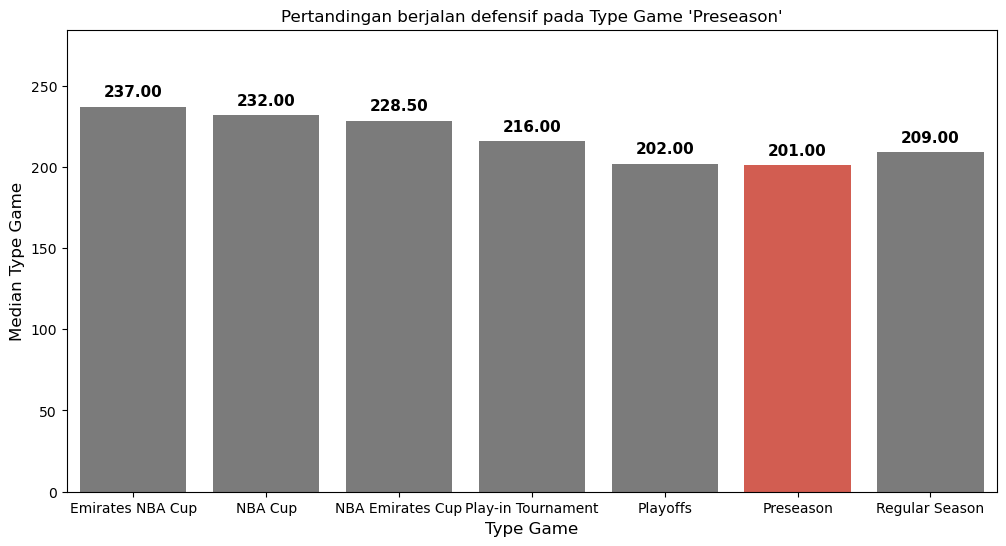

Tipe Game Preseason terbukti berjalan lebih defensif dengan score lebih rendah 201.0


In [116]:
#soal  nomor 4
#  4. Bandingkan nilai median dari total skor pertandingan untuk setiap kategori di gameType. Apakah tipe pertandingan tertentu terbukti berjalan lebih defensif (skor lebih rendah)?
data = df[['homeScore','awayScore','gameType']].copy()
data['total_score'] = data['homeScore']+data['awayScore']
median_typegame = data.groupby('gameType').agg(median_score=('total_score','median')).reset_index()
median_typegame

top_medianGame = median_typegame.loc[median_typegame['median_score'].idxmin()]
colors = ['#e74c3c' if (x == top_medianGame.median_score) else "#7b7b7b" for x in median_typegame['median_score']]

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=median_typegame, x='gameType', y='median_score', hue='gameType',palette=colors)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}', 
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 5),  # Jarak 5 point ke atas
                textcoords="offset points",
                ha='center', va='bottom', 
                fontweight='bold', fontsize=11)
plt.ylim(0, median_typegame['median_score'].max() * 1.2)
plt.title(f"Pertandingan berjalan defensif pada Type Game '{top_medianGame.gameType}'")
plt.xlabel('Type Game', fontsize=12)
plt.ylabel('Median Type Game',fontsize=12)
plt.show()
print(f"Tipe Game {top_medianGame.gameType} terbukti berjalan lebih defensif dengan score lebih rendah {top_medianGame.median_score}")

In [35]:
df.head(2)

,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameDate
0,42500175,2026-04-29 22:00:00,Los Angeles,Lakers,1610612747,Houston,Rockets,1610612745,93,99,1610612745,Playoffs,2026-04-29 22:00:00
1,42500135,2026-04-29 19:30:00,Cleveland,Cavaliers,1610612739,Toronto,Raptors,1610612761,125,120,1610612739,Playoffs,2026-04-29 19:30:00


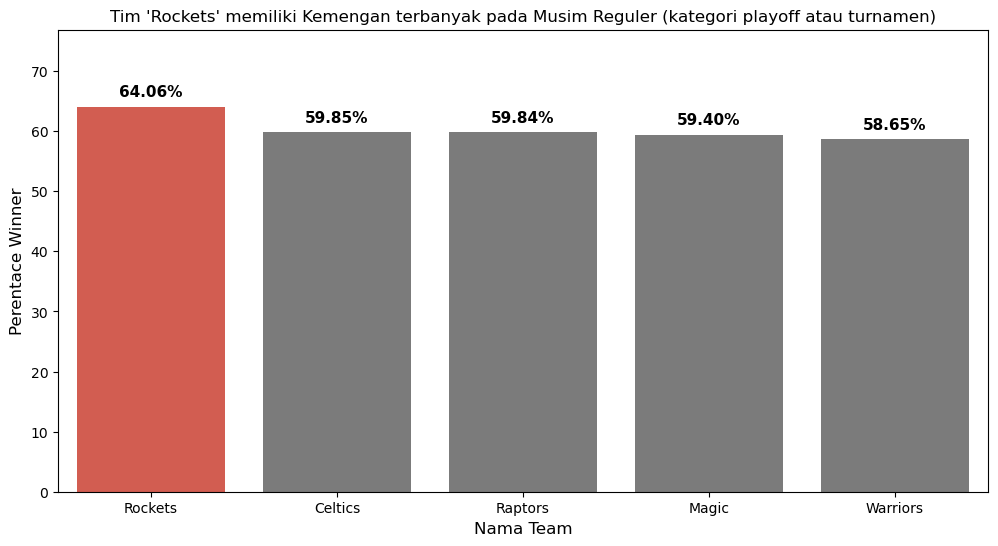

Tim 'Rockets' memiliki Kemengan terbanyak sebesar 64.06%


In [135]:
#soal nomor 5
# 5. Identifikasi tim yang memiliki persentase kemenangan tertinggi khusus pada gameType yang bukan musim reguler (misal: kategori playoff atau turnamen).
data=df[['winner','awayteamId','hometeamId','gameType','hometeamName','awayteamName']].copy()
filteredTypeGame = (data.loc[~data['gameType'].isin(['Playoffs','Regular Season'])])

main_kandang = filteredTypeGame['awayteamId'].value_counts()
main_tandang = filteredTypeGame['hometeamId'].value_counts()
total_laga = main_kandang.add(main_tandang,fill_value=0)

count_winnerTeam = filteredTypeGame.groupby('winner').agg(count_winner=('winner', 'count')).reset_index()
#Gabungkan tabel kemenangan dengan total pertandingan berdasarkan ID Tim
data_gabungan = pd.merge(count_winnerTeam,total_laga.to_frame('total_laga'),left_on='winner',right_index=True,how='inner')
data_gabungan['percentace'] = ((data_gabungan['count_winner']/data_gabungan['total_laga'])*100).round(2)

# Membuat master dictionary untuk semua ID tim dan nama kotanya
home_dict = data.set_index('hometeamId')['hometeamName'].to_dict()
away_dict = data.set_index('awayteamId')['awayteamName'].to_dict()
# Menggabungkan kedua dictionary agar mencakup seluruh tim
team_lookup = {**home_dict, **away_dict}
data_gabungan['Nama_Team'] = data_gabungan['winner'].map(team_lookup)


filtered_team = data_gabungan.sort_values(by='percentace',ascending=False).head(5).reset_index(drop=True)
top_team = filtered_team.loc[filtered_team['percentace'].idxmax()]
colors = ['#e74c3c' if (x == top_team.percentace) else "#7b7b7b" for x in filtered_team['percentace']]

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=filtered_team, x='Nama_Team', y='percentace', hue='Nama_Team',palette=colors)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}%', 
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 5),  # Jarak 5 point ke atas
                textcoords="offset points",
                ha='center', va='bottom', 
                fontweight='bold', fontsize=11)
plt.ylim(0, filtered_team['percentace'].max() * 1.2)
plt.title(f"Tim '{top_team.Nama_Team}' memiliki Kemengan terbanyak pada Musim Reguler (kategori playoff atau turnamen)")
plt.xlabel('Nama Team', fontsize=12)
plt.ylabel('Perentace Winner',fontsize=12)
plt.show()
print(f"Tim '{top_team.Nama_Team}' memiliki Kemengan terbanyak sebesar {top_team.percentace}%")

## Analisis Distribusi Skor, Kontribusi Poin, dan Dominasi Klasemen

   1. Buat fitur baru yang menghitung persentase kontribusi poin tim tuan rumah terhadap total skor pertandingan (homeScore / (homeScore + awayScore)). Tim mana yang memiliki rasio kontribusi tertinggi saat bermain di kandang?
   2. Hitung rata-rata skor yang dicetak (points scored) dan rata-rata kebobolan (points allowed) untuk setiap tim di sepanjang dataset. Tampilkan 3 tim dengan produktivitas serangan terbaik dan 3 tim dengan pertahanan terkuat.
   3. Hitung selisih skor absolut antara kedua tim di setiap laga. Tentukan nilai rata-rata, median, dan modus dari selisih skor tersebut untuk melihat seberapa ketat peta persaingan liga secara umum.
   4. Gunakan kolom winner untuk menghitung total jumlah kemenangan dari setiap tim (gabungan saat menjadi home maupun away). Urutkan tim dari yang mengoleksi kemenangan terbanyak hingga tersedikit.
   5. Berapa persen pertandingan dalam dataset yang berakhir dengan selisih skor sangat tipis (misal $\le 3$ poin)? Kelompokkan hasil persentase ini berdasarkan masing-masing gameType untuk melihat di fase mana laga sengit paling sering terjadi.

In [37]:
df.head(2)

,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameDate
0,42500175,2026-04-29 22:00:00,Los Angeles,Lakers,1610612747,Houston,Rockets,1610612745,93,99,1610612745,Playoffs,2026-04-29 22:00:00
1,42500135,2026-04-29 19:30:00,Cleveland,Cavaliers,1610612739,Toronto,Raptors,1610612761,125,120,1610612739,Playoffs,2026-04-29 19:30:00


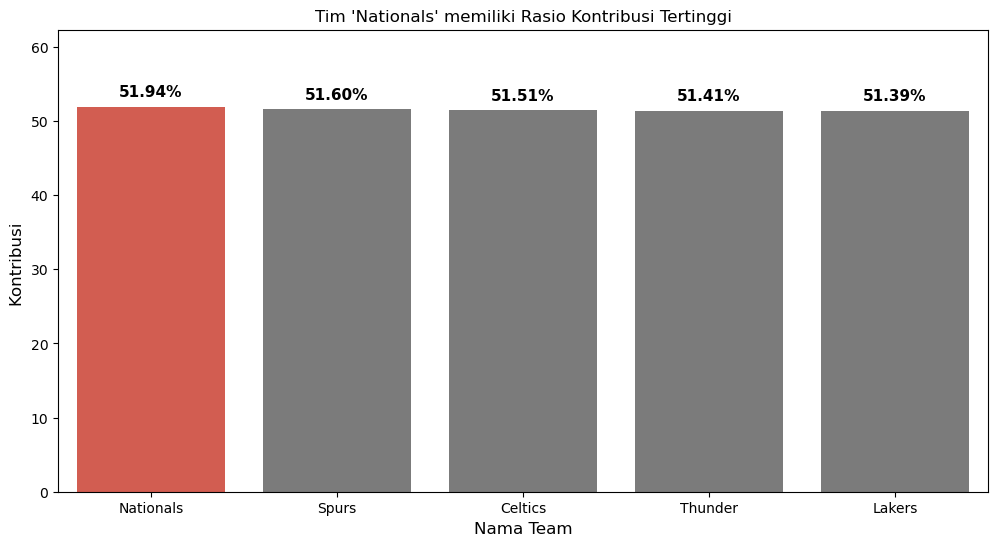

TIm dengan Rasio Tertinggi adalah Nationals sebesar 51.94%


In [144]:
#soal nomor 1
# 1. Buat fitur baru yang menghitung persentase kontribusi poin tim tuan rumah terhadap total skor pertandingan (homeScore / (homeScore + awayScore)). Tim mana yang memiliki rasio kontribusi tertinggi saat bermain di kandang?
data = df[['hometeamName','homeScore','awayScore']].copy()
data['contributore_point'] = ((data['homeScore']/(data['homeScore']+data['awayScore']))*100).round(2)
avg_team = data.groupby('hometeamName')['contributore_point'].mean().reset_index().sort_values(by='contributore_point',ascending=False).round(2).head(5)
top_team = avg_team.loc[avg_team['contributore_point'].idxmax()]
colors = ['#e74c3c' if (x == top_team.contributore_point) else "#7b7b7b" for x in avg_team['contributore_point']]

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=avg_team, x='hometeamName', y='contributore_point', hue='hometeamName',palette=colors)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}%', 
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 5),  # Jarak 5 point ke atas
                textcoords="offset points",
                ha='center', va='bottom', 
                fontweight='bold', fontsize=11)
plt.ylim(0, avg_team['contributore_point'].max() * 1.2)
plt.title(f"Tim '{top_team.hometeamName}' memiliki Rasio Kontribusi Tertinggi")
plt.xlabel('Nama Team', fontsize=12)
plt.ylabel('Kontribusi ',fontsize=12)
plt.show()

print(f"TIm dengan Rasio Tertinggi adalah {top_team.hometeamName} sebesar {top_team.contributore_point}%")

In [39]:
df.head(2)

,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameDate
0,42500175,2026-04-29 22:00:00,Los Angeles,Lakers,1610612747,Houston,Rockets,1610612745,93,99,1610612745,Playoffs,2026-04-29 22:00:00
1,42500135,2026-04-29 19:30:00,Cleveland,Cavaliers,1610612739,Toronto,Raptors,1610612761,125,120,1610612739,Playoffs,2026-04-29 19:30:00


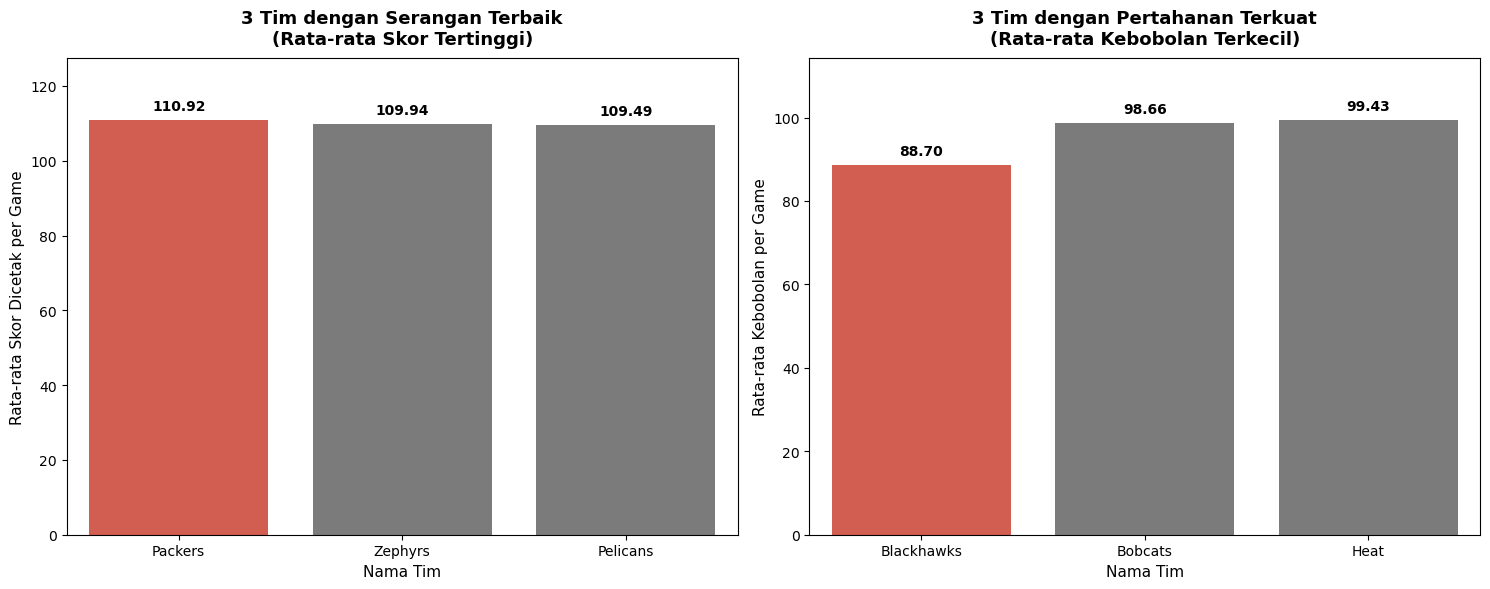

=== 3 Tim dengan Produktivitas Serangan Terbaik ===
       Team  avg_scored
0   Packers      110.92
1   Zephyrs      109.94
2  Pelicans      109.49

=== 3 Tim dengan Pertahanan Terkuat ===
         Team  avg_allowed
0  Blackhawks        88.70
1     Bobcats        98.66
2        Heat        99.43


In [ ]:
#soal nomor 2
# 2. Hitung rata-rata skor yang dicetak (points scored) dan rata-rata kebobolan (points allowed) untuk setiap tim di sepanjang dataset. Tampilkan 3 tim dengan produktivitas serangan terbaik dan 3 tim dengan pertahanan terkuat.
# 1. Siapkan data dasar
data = df[['hometeamName', 'awayteamName', 'homeScore', 'awayScore']].copy()

# --- BAGIAN A: HITUNG TOTAL POIN & PERTANDINGAN HOME ---
home_stats = data.groupby('hometeamName').agg(
    home_scored=('homeScore', 'sum'),
    home_allowed=('awayScore', 'sum'),
    home_games=('homeScore', 'count')
).reset_index().rename(columns={'hometeamName': 'Team'})

# --- BAGIAN B: HITUNG TOTAL POIN & PERTANDINGAN AWAY ---
away_stats = data.groupby('awayteamName').agg(
    away_scored=('awayScore', 'sum'),
    away_allowed=('homeScore', 'sum'),
    away_games=('awayScore', 'count')
).reset_index().rename(columns={'awayteamName': 'Team'})

# --- BAGIAN C: GABUNGKAN & HITUNG RATA-RATA ---
total_stats = pd.merge(home_stats, away_stats, on='Team')

# Total pertandingan, skor, dan kebobolan
total_stats['total_games'] = total_stats['home_games'] + total_stats['away_games']
total_stats['total_scored'] = total_stats['home_scored'] + total_stats['away_scored']
total_stats['total_allowed'] = total_stats['home_allowed'] + total_stats['away_allowed']

# Hitung Rata-rata (Sesuai Permintaan Soal)
total_stats['avg_scored'] = (total_stats['total_scored'] / total_stats['total_games']).round(2)
total_stats['avg_allowed'] = (total_stats['total_allowed'] / total_stats['total_games']).round(2)

# --- BAGIAN D: TAMPILKAN HASIL SESUAI PERTANYAAN ---

# 3 Tim dengan Produktivitas Serangan Terbaik (Rata-rata Skor Tertinggi)
top3_attack = total_stats.sort_values(by='avg_scored', ascending=False)[['Team', 'avg_scored']].head(3).reset_index(drop=True)

# 3 Tim dengan Pertahanan Terkuat (Rata-rata Kebobolan Terkecil)
top3_defense = total_stats.sort_values(by='avg_allowed', ascending=True)[['Team', 'avg_allowed']].head(3).reset_index(drop=True)


# --- BAGIAN VISUALISASI ---
# 1. Tentukan tim terbaik untuk highlight warna
best_attack_team = top3_attack.loc[top3_attack['avg_scored'].idxmax()]
best_defense_team = top3_defense.loc[top3_defense['avg_allowed'].idxmin()] # Nilai kebobolan terkecil adalah yang terbaik

# 2. Atur skema warna kondisional
colors_attack = ['#e74c3c' if (x == best_attack_team['avg_scored']) else "#7b7b7b" for x in top3_attack['avg_scored']]
colors_defense = ['#e74c3c' if (x == best_defense_team['avg_allowed']) else "#7b7b7b" for x in top3_defense['avg_allowed']]

# 3. Membuat kontainer grafik berdampingan (1 baris, 2 kolom)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- GRAFIK 1: PRODUKTIVITAS SERANGAN (KIRI) ---
ax1 = sns.barplot(ax=axes[0], data=top3_attack, x='Team', y='avg_scored', hue='Team', palette=colors_attack, legend=False)
axes[0].set_title("3 Tim dengan Serangan Terbaik\n(Rata-rata Skor Tertinggi)", fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel("Nama Tim", fontsize=11)
axes[0].set_ylabel("Rata-rata Skor Dicetak per Game", fontsize=11)
axes[0].set_ylim(0, top3_attack['avg_scored'].max() * 1.15)

# Teks angka di atas batang serangan
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f'{height:.2f}', xy=(p.get_x() + p.get_width() / 2, height),
                 xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

# --- GRAFIK 2: PERTAHANAN TERKUAT (KANAN) ---
ax2 = sns.barplot(ax=axes[1], data=top3_defense, x='Team', y='avg_allowed', hue='Team', palette=colors_defense, legend=False)
axes[1].set_title("3 Tim dengan Pertahanan Terkuat\n(Rata-rata Kebobolan Terkecil)", fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel("Nama Tim", fontsize=11)
axes[1].set_ylabel("Rata-rata Kebobolan per Game", fontsize=11)
axes[1].set_ylim(0, top3_defense['avg_allowed'].max() * 1.15)

# Teks angka di atas batang pertahanan
for p in ax2.patches:
    height = p.get_height()
    ax2.annotate(f'{height:.2f}', xy=(p.get_x() + p.get_width() / 2, height),
                 xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

# Merapikan tata letak grafik
plt.tight_layout()
plt.show()


In [41]:
df.head(2)

,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameDate
0,42500175,2026-04-29 22:00:00,Los Angeles,Lakers,1610612747,Houston,Rockets,1610612745,93,99,1610612745,Playoffs,2026-04-29 22:00:00
1,42500135,2026-04-29 19:30:00,Cleveland,Cavaliers,1610612739,Toronto,Raptors,1610612761,125,120,1610612739,Playoffs,2026-04-29 19:30:00


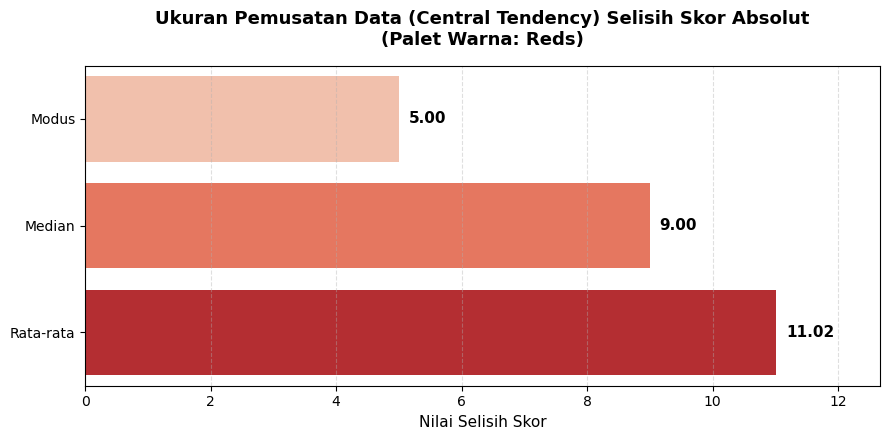

In [151]:
#soal nomor 3
# 3. Hitung selisih skor absolut antara kedua tim di setiap laga. Tentukan nilai rata-rata, median, dan modus dari selisih skor tersebut untuk melihat seberapa ketat peta persaingan liga secara umum.
data = df[['hometeamName','awayteamName','homeScore','awayScore']].copy()
data['absolute_difference'] = (data['homeScore'] - data['awayScore']).abs()
hasil = {
    'Rata-rata': data['absolute_difference'].mean(),
    'Median': data['absolute_difference'].median(),
    'Modus': data['absolute_difference'].mode().iloc[0] 
             if not data['absolute_difference'].mode().empty else None
}
summary = pd.DataFrame([hasil])
# 1. Mengubah struktur data dari horizontal menjadi vertikal (Melting)
summary_melted = summary.melt(var_name='Metrik', value_name='Nilai')
summary_melted = summary_melted.sort_values(by='Nilai').reset_index(drop=True)

plt.figure(figsize=(9, 4.5))
ax = sns.barplot(data=summary_melted, x='Nilai', y='Metrik',  hue='Metrik',  palette='Reds',  legend=False)

for p in ax.patches:
    width = p.get_width()
    if width >= 0:
        ax.annotate(
            f'{width:.2f}', 
            xy=(width, p.get_y() + p.get_height() / 2),
            xytext=(7, 0),  # Jarak 7 poin ke arah kanan
            textcoords="offset points",ha='left', va='center',  fontweight='bold', fontsize=11)

plt.xlim(0, summary_melted['Nilai'].max() * 1.15)  
plt.title("Ukuran Pemusatan Data (Central Tendency) Selisih Skor Absolut\n(Palet Warna: Reds)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Nilai Selisih Skor', fontsize=11)
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.4)  # Garis bantu vertikal tipis
plt.tight_layout()
plt.show()

In [138]:
df.head(2)

,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameDate
0,42500175,2026-04-29 22:00:00,Los Angeles,Lakers,1610612747,Houston,Rockets,1610612745,93,99,1610612745,Playoffs,2026-04-29 22:00:00
1,42500135,2026-04-29 19:30:00,Cleveland,Cavaliers,1610612739,Toronto,Raptors,1610612761,125,120,1610612739,Playoffs,2026-04-29 19:30:00


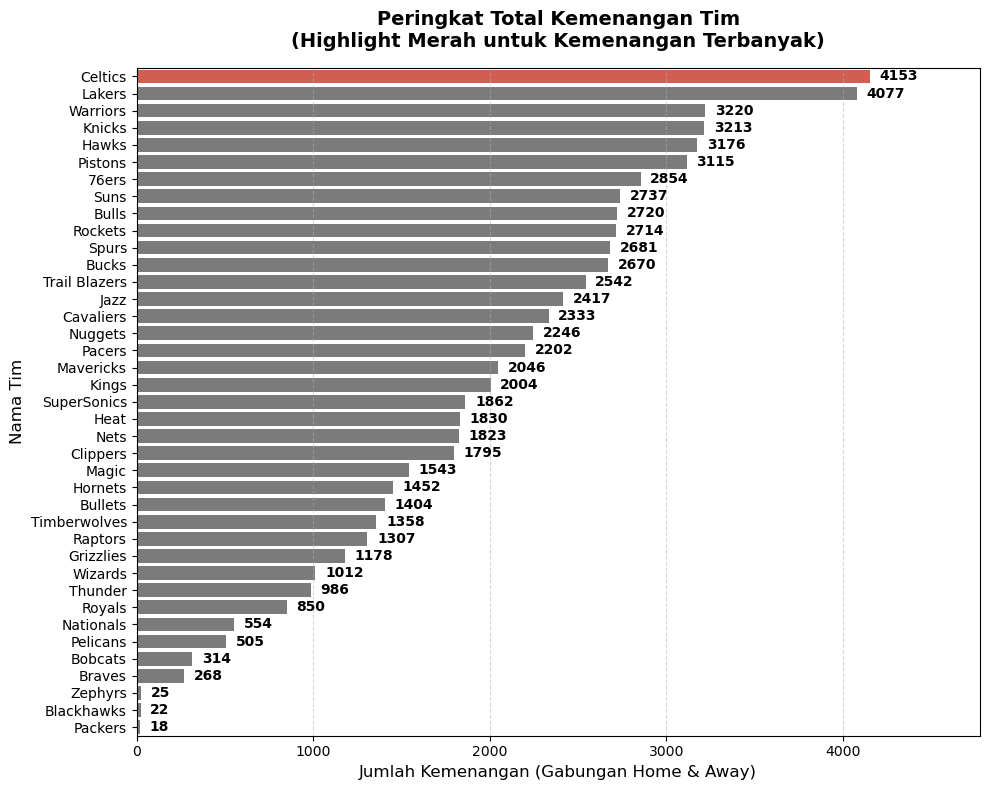

In [ ]:
# soal nomor 4
# 4.Gunakan kolom winner untuk menghitung total jumlah kemenangan dari setiap tim (gabungan saat menjadi home maupun away). Urutkan tim dari yang mengoleksi kemenangan terbanyak hingga tersedikit.
data = df[['hometeamId','awayteamId','hometeamName','awayteamName','winner']].copy()
team_winnerHome = data.loc[data['hometeamId'] == data['winner']].drop(columns=['awayteamId','awayteamName'])
team_winnerAway = data.loc[data['awayteamId'] == data['winner']].drop(columns=['hometeamId','hometeamName'])

winner_home = team_winnerHome.groupby('hometeamName')['winner'].count().reset_index()
winner_away = team_winnerAway.groupby('awayteamName')['winner'].count().reset_index()

winner_home = winner_home.rename(columns={'hometeamName':'Team'})
winner_away = winner_away.rename(columns={'awayteamName':'Team'})

total_winner = pd.merge(winner_home,winner_away,on='Team',how='outer')
total_winner = total_winner.fillna(0)

total_winner['total_winner'] = total_winner['winner_x'] + total_winner['winner_y']
sorting_winner = total_winner.sort_values(by='total_winner',ascending=False).reset_index(drop=True)

max_win_val = sorting_winner['total_winner'].max()
colors = ['#e74c3c' if (x == max_win_val) else "#7b7b7b" for x in sorting_winner['total_winner']]

plt.figure(figsize=(10, 8))
ax = sns.barplot(data=sorting_winner, x='total_winner', y='Team', hue='Team', palette=colors, legend=False)

for p in ax.patches:
    width = p.get_width()
    if width >= 0:  # Memastikan bar memiliki nilai valid sebelum diberi label
        ax.annotate(
            f'{int(width)}', xy=(width, p.get_y() + p.get_height() / 2),
            xytext=(7, 0),  # Jarak 7 poin ke arah kanan
            textcoords="offset points",ha='left', va='center', fontweight='bold', fontsize=10)
        
plt.xlim(0, max_win_val * 1.15)  
plt.title("Peringkat Total Kemenangan Tim\n(Highlight Merah untuk Kemenangan Terbanyak)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Jumlah Kemenangan (Gabungan Home & Away)', fontsize=12)
plt.ylabel('Nama Tim', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5) 
plt.tight_layout()
plt.show()

In [45]:
df.head(2)

,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameDate
0,42500175,2026-04-29 22:00:00,Los Angeles,Lakers,1610612747,Houston,Rockets,1610612745,93,99,1610612745,Playoffs,2026-04-29 22:00:00
1,42500135,2026-04-29 19:30:00,Cleveland,Cavaliers,1610612739,Toronto,Raptors,1610612761,125,120,1610612739,Playoffs,2026-04-29 19:30:00


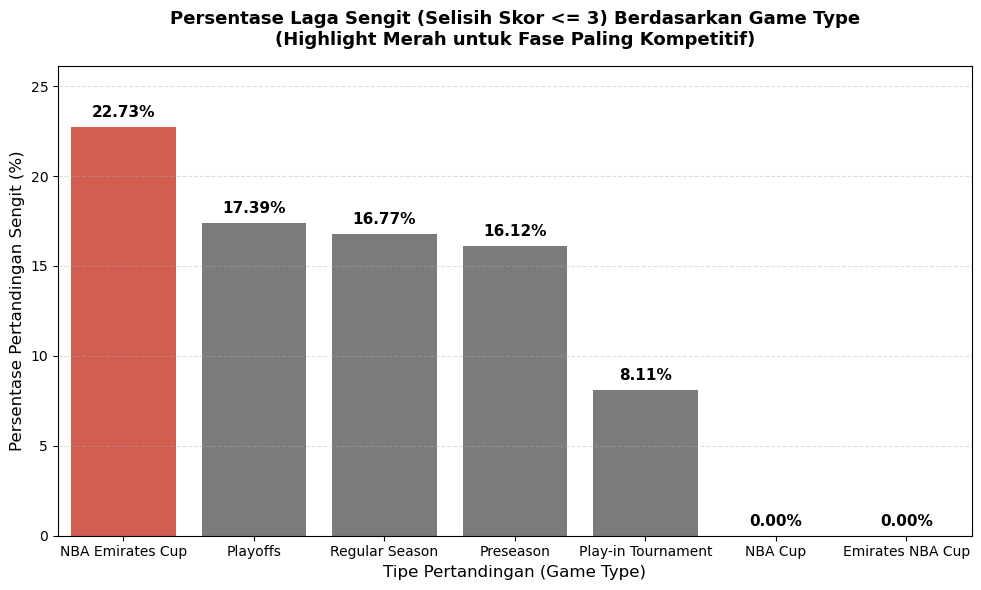

In [152]:
#soal nomor 5
# 5.Berapa persen pertandingan dalam dataset yang berakhir dengan selisih skor sangat tipis (misal <= 3 poin)? Kelompokkan hasil persentase ini berdasarkan masing-masing gameType untuk melihat di fase mana laga sengit paling sering terjadi.
data = df[['homeScore','awayScore','gameType']].copy()
data['score_diff'] = (data['homeScore']-data['awayScore']).abs()

tihgt_games = data.loc[data['score_diff'] <= 3]
all_games = data

summary_tight_games = tihgt_games.groupby('gameType').agg(tightGames_count=('score_diff','count')).reset_index()
summary_all_games = all_games.groupby('gameType').agg(allGames_count=('score_diff','count')).reset_index()

total_games = pd.merge(summary_all_games,summary_tight_games,on='gameType',how='outer')
total_games = total_games.fillna(0)
total_games['percentage'] = ((total_games['tightGames_count'] / total_games['allGames_count'])*100).round(2)

final_summary = total_games.sort_values(by='percentage', ascending=False).reset_index(drop=True)

max_pct_val = final_summary['percentage'].max()
colors = ['#e74c3c' if (x == max_pct_val) else "#7b7b7b" for x in final_summary['percentage']]

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=final_summary, x='gameType', y='percentage', hue='gameType', palette=colors, legend=False)

for p in ax.patches:
    height = p.get_height()
    if height >= 0:  # Memastikan bar memiliki nilai valid sebelum diberi label
        ax.annotate(
            f'{height:.2f}%', 
            xy=(p.get_x() + p.get_width() / 2, height),
            xytext=(0, 5),  # Jarak 5 poin ke arah atas
            textcoords="offset points", ha='center', va='bottom', fontweight='bold', fontsize=11)


plt.ylim(0, max_pct_val * 1.15) 
plt.title("Persentase Laga Sengit (Selisih Skor <= 3) Berdasarkan Game Type\n(Highlight Merah untuk Fase Paling Kompetitif)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Tipe Pertandingan (Game Type)', fontsize=12)
plt.ylabel('Persentase Pertandingan Sengit (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)  # Menambahkan garis bantu horizontal tipis
plt.tight_layout()
plt.show()